In [334]:
import pandas as pd
import numpy as np
import seaborn as sns

In [335]:
df_TCS = pd.read_csv("Data\IT_Data\TCS.NS_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\vishe\AppData\Local\Temp\ipykernel_28852\3603683878.py:1: SyntaxWarning: invalid escape sequence '\I'
  df_TCS = pd.read_csv("Data\IT_Data\TCS.NS_data.csv")


In [336]:
df_TCS.info()

<class 'pandas.DataFrame'>
RangeIndex: 2759 entries, 0 to 2758
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2759 non-null   str  
 1   Close   2758 non-null   str  
 2   High    2758 non-null   str  
 3   Low     2758 non-null   str  
 4   Open    2758 non-null   str  
 5   Volume  2758 non-null   str  
dtypes: str(6)
memory usage: 129.5 KB


In [337]:
df_TCS.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,988.879638671875,997.2123838772336,987.1120636665565,997.2123838772336,366830
3,2015-01-02,1002.0490112304688,1006.516461209064,990.8415957982204,990.9969474257879,925740
4,2015-01-05,986.820556640625,1009.9929805494601,980.7603275085361,1002.6508637690987,1754242


In [338]:
df_TCS.describe()

,Price,Close,High,Low,Open,Volume
count,2759,2758,2758,2758,2758,2758
unique,2759,2742,2757,2758,2758,2757
top,Ticker,3380.860107421875,3160.0,TCS.NS,TCS.NS,0
freq,1,3,2,1,1,2


In [339]:
df_TCS = df_TCS.rename(columns={'Price':'Date'})

In [340]:
df_TCS = df_TCS.iloc[2:].reset_index(drop=True)

In [341]:
df_TCS['Date'] = pd.to_datetime(df_TCS['Date'])

decimal_values = ["Close", "High", "Low", "Open", "Volume"]
numeric_values =["Volume"]

for i in decimal_values:
    df_TCS[i] = df_TCS[i].astype(float)

for j in numeric_values:
    df_TCS[j] = pd.to_numeric(df_TCS[j])

In [342]:
df_TCS = df_TCS.sort_values(by="Date").reset_index(drop=True)

### Visualize The Trends

In [343]:
import matplotlib.pyplot as plt

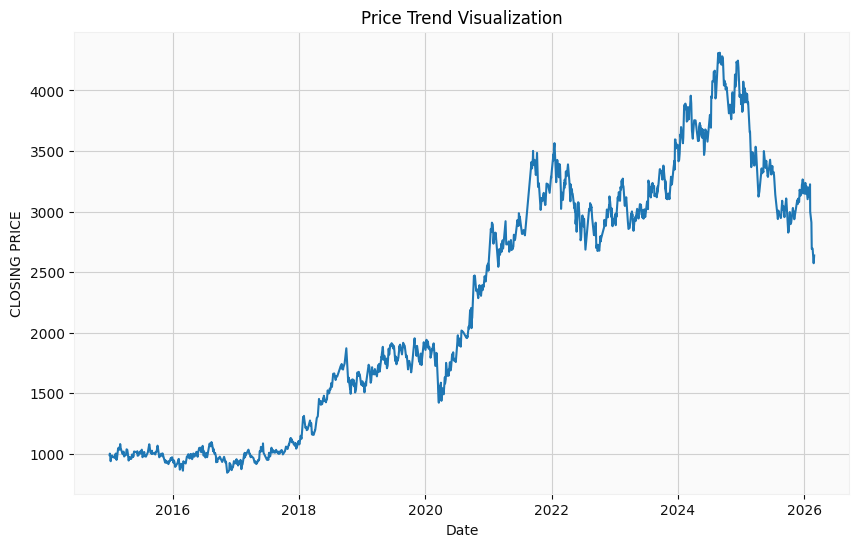

In [344]:
# Price Trend Over the Time
plt.figure(figsize=(10,6))
plt.plot(df_TCS['Date'], df_TCS['Close'], )
plt.title("Price Trend Visualization")
plt.xlabel("Date")
plt.ylabel("CLOSING PRICE")
plt.show()

<Figure size 1000x600 with 0 Axes>

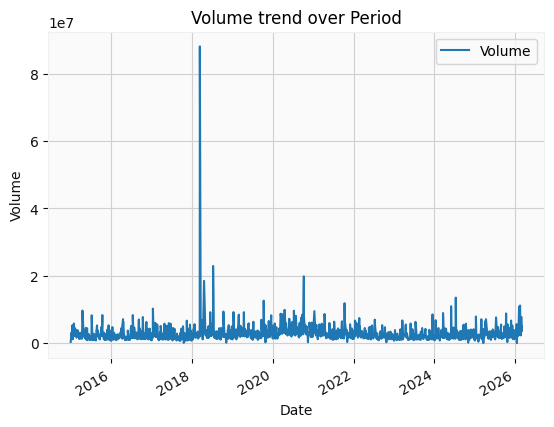

In [345]:
# Volume trend Over Time
plt.figure(figsize=(10,6))
df_TCS.plot(x='Date', y='Volume', kind='line', title="Volume trend over Period")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

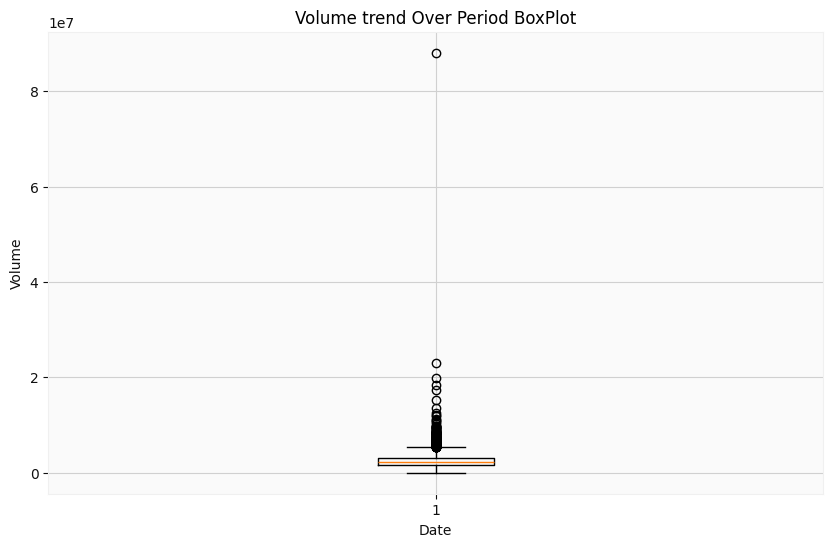

In [346]:
# The Line shows a Outlier in Volume . Check it using Box Plot
plt.figure(figsize=(10,6))
plt.boxplot(df_TCS["Volume"])
plt.title("Volume trend Over Period BoxPlot")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Daily Returns on Stocks

In [347]:
def daily_returns(close_price):
    returns=[None]
    for i in range(1, len(close_price)):
        daily_return = (close_price[i] - close_price[i-1])/close_price[i-1]
        returns.append(daily_return)
    return returns

df_TCS['Daily_Returns'] = daily_returns(df_TCS['Close'])

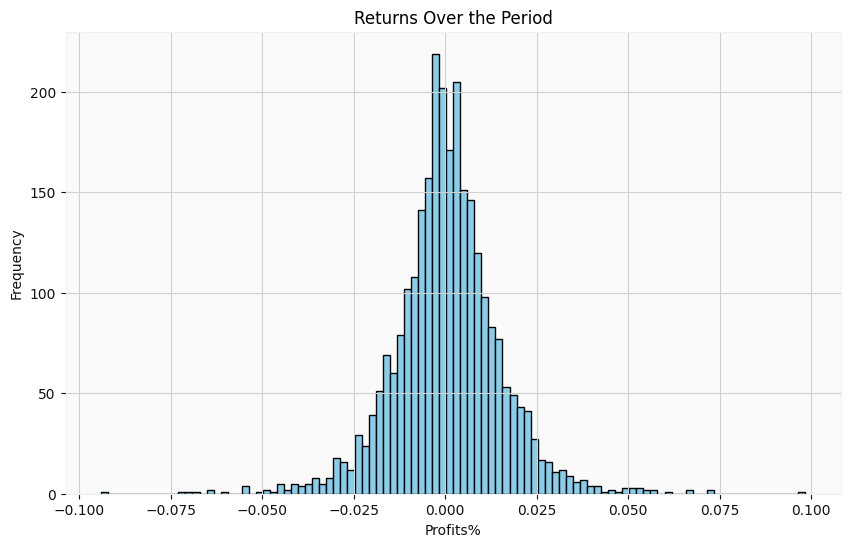

In [348]:
# Visualization of the Returns
plt.figure(figsize=(10,6))
plt.hist(df_TCS['Daily_Returns'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel("Profits%")
plt.ylabel("Frequency")
plt.title("Returns Over the Period")
plt.grid(True)
plt.show()

### Calculating Moving Averages Across the Range

In [349]:
df_TCS['MA_Week'] = df_TCS['Close'].rolling(window=7).mean()
df_TCS['MA_Month'] = df_TCS['Close'].rolling(window=30).mean()
df_TCS['MA_3Months'] = df_TCS['Close'].rolling(window=90).mean()

In [350]:
df_TCS.head(10)

,Date,Close,High,Low,Open,Volume,Daily_Returns,MA_Week,MA_Month,MA_3Months
0,2015-01-01,988.879639,997.212384,987.112064,997.212384,366830.0,NaN,NaN,NaN,NaN
1,2015-01-02,1002.049011,1006.516461,990.841596,990.996947,925740.0,0.013317,NaN,NaN,NaN
2,2015-01-05,986.820557,1009.992981,980.760328,1002.650864,1754242.0,-0.015197,NaN,NaN,NaN
3,2015-01-06,950.440369,982.489468,947.876403,982.489468,2423784.0,-0.036866,NaN,NaN,NaN
4,2015-01-07,939.213501,963.085208,935.231643,959.530709,2636332.0,-0.011812,NaN,NaN,NaN
5,2015-01-08,949.352600,951.372646,940.320581,948.808680,1565408.0,0.010795,NaN,NaN,NaN
6,2015-01-09,975.962891,978.915235,951.760950,953.703320,3197642.0,0.028030,970.388367,NaN,NaN
7,2015-01-12,974.953003,982.062095,963.512465,977.788882,1596006.0,-0.001035,968.398847,NaN,NaN
8,2015-01-13,970.368713,982.994112,963.453955,978.954023,1468432.0,-0.004702,963.873090,NaN,NaN
9,2015-01-14,979.711914,983.538421,971.379166,977.400513,1787096.0,0.009629,962.857570,NaN,NaN


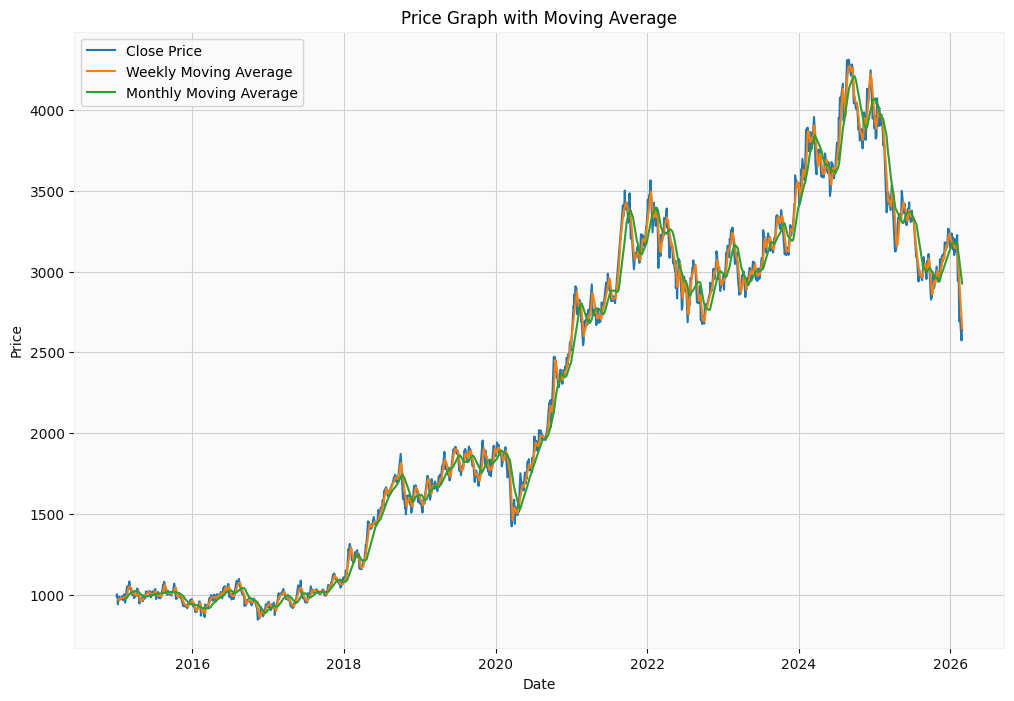

In [351]:
plt.figure(figsize=(12,8))
plt.plot(df_TCS['Date'], df_TCS['Close'], label='Close Price')
plt.plot(df_TCS['Date'], df_TCS['MA_Week'], label='Weekly Moving Average')
plt.plot(df_TCS['Date'], df_TCS['MA_Month'], label="Monthly Moving Average")
plt.title("Price Graph with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [352]:
df_TCS.isnull().sum()

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Daily_Returns     1
MA_Week           6
MA_Month         29
MA_3Months       89
dtype: int64

c:\Users\vishe\OneDrive\Desktop\SUL_PROJECT\.venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


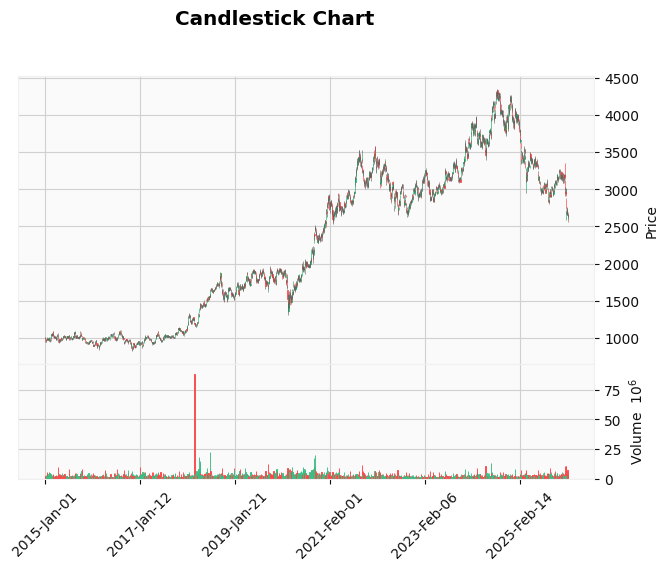

In [353]:
# CandleStick type of Chart
import mplfinance as mpf


# before that set the date column as index column
df_TCS = df_TCS.set_index('Date')
df_TCS = df_TCS.sort_index()

mpf.plot(df_TCS, type='candle', style='yahoo', title=f'Candlestick Chart', volume=True)


In [354]:
# Volatility to Measure the High Risk Periods
df_TCS['volatility'] = df_TCS['Daily_Returns'].rolling(window=3).std()

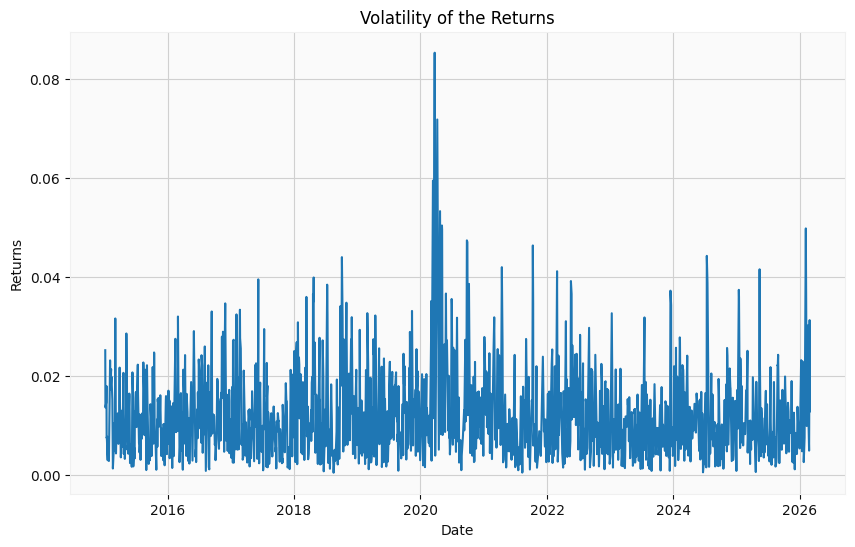

In [355]:
# Plot Date VS Volatily
plt.figure(figsize=(10,6))
plt.plot(df_TCS.index,df_TCS['volatility'])
plt.title("Volatility of the Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

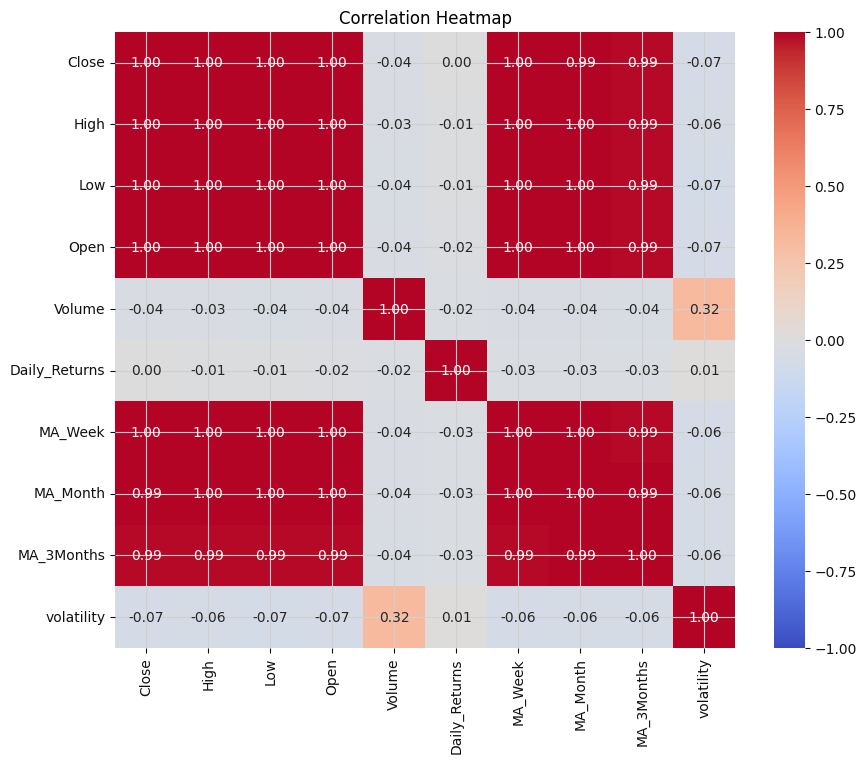

In [356]:
# Check the Correlation between all the calculated values
corr_matrix = df_TCS.select_dtypes('number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

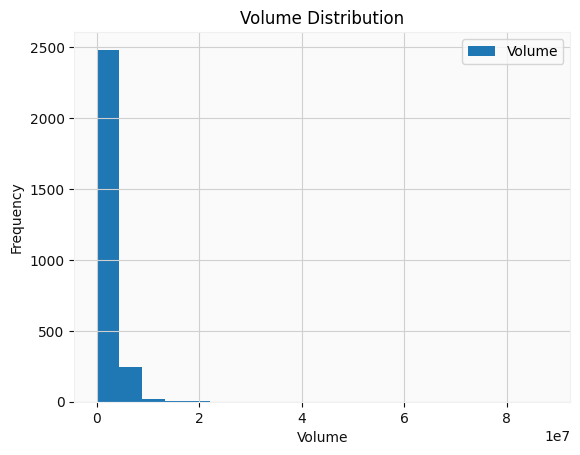

In [357]:
# Plot Histogram for Volume to check for trading activity 
df_TCS.plot(kind='hist', y='Volume', bins=20, title='Volume Distribution')
plt.xlabel("Volume")
plt.show()

In [358]:
# Computing RSI (Relative Strength Index) , it measures speed and magnitude of Price Movements

# RSI compares (Average Gains VS Average Losses)

delta = df_TCS['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss

df_TCS['RSI'] = 100-(100/(1+rs))

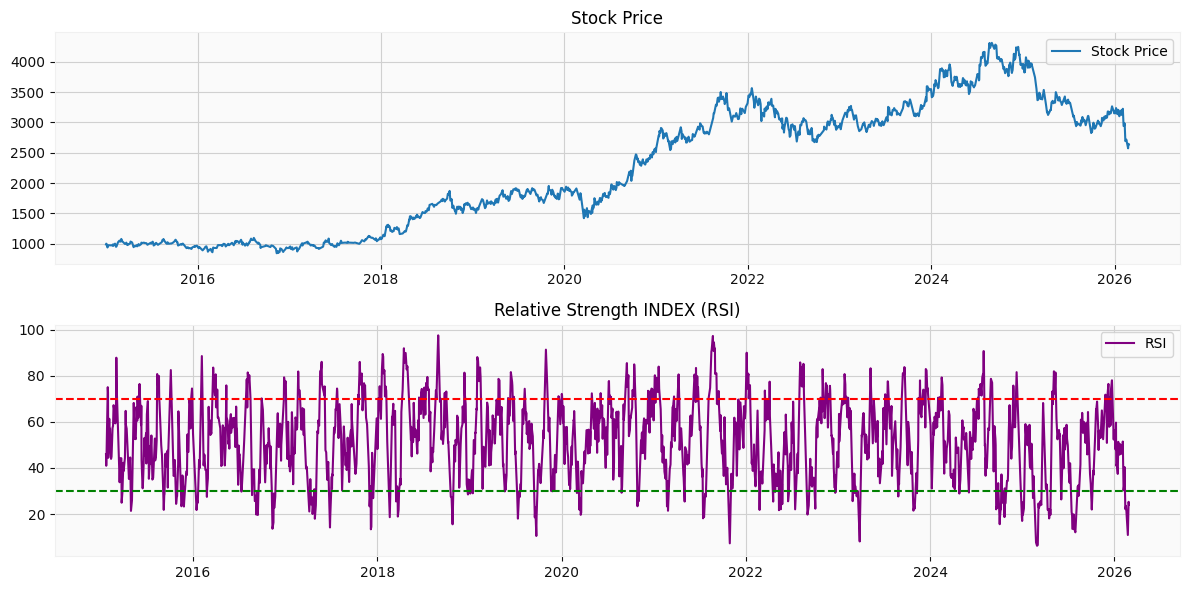

In [359]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df_TCS['Close'], label= "Stock Price")
plt.title("Stock Price")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df_TCS['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red')  # threshold when stock is overbought
plt.axhline(30, linestyle='--', color='green') # threshold when stock is oversold

plt.title("Relative Strength INDEX (RSI)")

plt.legend()
plt.tight_layout()
plt.show()

### Creating Prediction Target

In [360]:
# if next day's return > 0 then target = 1 else 0


df_TCS['Next_Day_Return'] = df_TCS['Daily_Returns'].shift(-1)
df_TCS['Target'] = (df_TCS['Next_Day_Return'] > 0).astype(int)

In [361]:
df_TCS = df_TCS.dropna()

In [362]:
df_TCS.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2667 entries, 2015-05-15 to 2026-02-26
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            2667 non-null   float64
 1   High             2667 non-null   float64
 2   Low              2667 non-null   float64
 3   Open             2667 non-null   float64
 4   Volume           2667 non-null   float64
 5   Daily_Returns    2667 non-null   float64
 6   MA_Week          2667 non-null   float64
 7   MA_Month         2667 non-null   float64
 8   MA_3Months       2667 non-null   float64
 9   volatility       2667 non-null   float64
 10  RSI              2667 non-null   float64
 11  Next_Day_Return  2667 non-null   float64
 12  Target           2667 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 291.7 KB


### Time Based Train Test Split

In [363]:
df_TCS = df_TCS.sort_index()
split_index = int(len(df_TCS)*0.8)

train = df_TCS.iloc[0:split_index]
test = df_TCS.iloc[split_index: len(df_TCS)]


print(f"Training ENDS: {train.index.max()}")
print(f"Testing Starts: {test.index.min()}")

Training ENDS: 2024-01-01 00:00:00
Testing Starts: 2024-01-02 00:00:00


In [365]:
y_train = train['Target']
y_test = test['Target']



features=['Daily_Returns', 'Volume', 'volatility', 'MA_Week', 'MA_Month', 'MA_3Months', 'RSI']
X_train = train[features]
X_test = test[features]

### Fearture Scaling

In [369]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()